# Aggregate public ATST controls by isolate ID

Read all eight linked ATST studies. Count each `ISOLATE_ID` once per study file using its `ENTITIES.ISOLATES` species. For this example, treat Costa 2024 and Bürkle 2025 `PAO1` as the same isolate. Compare their OD600 assay conditions and uninfected controls; convert plot time to hours.


In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ATST import read_atst, ATSTFile, MultiReadoutATST

warnings.filterwarnings(
    "ignore", message="READOUT_IDS contains only one readout_id value"
)
root = Path.cwd()
if root.name != "Public data ":
    root = root / "examples" / "Public data "
manifests = sorted(root.glob("*/atst_*/*.atst.txt"))
assert len(manifests) == 8, f"Expected eight public ATST files; found {len(manifests)}"

seen_species = set()
isolate_species = {}
isolate_counts = Counter()
isolate_files = defaultdict(list)
studies: dict[Path, MultiReadoutATST] = {}


## Inventory isolate species across studies

Check that each study has an `ISOLATES` entity table with `ISOLATE_ID` and `species`. Count an ID once per ATST file and retain its source file for the comparison below.


In [2]:
for manifest in manifests:
    study = read_atst(manifest, multi_readouts=True)
    studies[manifest] = study
    tables = study.entities.tables if study.entities else {}
    if "ISOLATES" not in tables:
        print(f"Skipping {manifest}: no ISOLATES entity table")
        continue
    isolates = tables["ISOLATES"].data
    if not {"ISOLATE_ID", "species"}.issubset(isolates.columns):
        print(f"Skipping {manifest}: ISOLATES lacks ISOLATE_ID or species")
        continue
    for isolate_id, species in isolates[["ISOLATE_ID", "species"]].itertuples(
        index=False, name=None
    ):
        if isolate_id in isolate_species and isolate_species[isolate_id] != species:
            raise ValueError(
                f"Conflicting species for {isolate_id}: {isolate_species[isolate_id]} versus {species}"
            )
        seen_species.add(species)
        isolate_species[isolate_id] = species
        isolate_counts[isolate_id] += 1
        isolate_files[isolate_id].append(manifest)

print(f"Read {len(studies)} ATST files; species: {', '.join(sorted(seen_species))}")


Read 8 ATST files; species: Escherichia coli, Pseudomonas aeruginosa


## Select the most frequent *Pseudomonas aeruginosa* isolate

Frequency means the number of distinct ATST study files containing the exact `ISOLATE_ID`; constructs keep their own IDs.


In [3]:
pseudomonas_ids = sorted(
    isolate_id
    for isolate_id, species in isolate_species.items()
    if species == "Pseudomonas aeruginosa"
)
print("Pseudomonas aeruginosa isolate IDs:", ", ".join(pseudomonas_ids))
most_used = max(pseudomonas_ids, key=lambda isolate_id: isolate_counts[isolate_id])
print(f"Most frequent: {most_used} ({isolate_counts[most_used]} studies)")
print("Studies containing it:")
for manifest in isolate_files[most_used]:
    print(f"  {studies[manifest].study.data['study_id']}: {manifest}")


Pseudomonas aeruginosa isolate IDs: ATCC_27853, BOIJ02, CHA, Lfar01, PA14, PAO1, PAO1_AVAST_Type_V, PAO1_CBASS_Type_III, PAO1_CBASS_Type_II_A, PAO1_CBASS_Type_II_C, PAO1_Druantia_Type_III, PAO1_QatABCD, PAO1_RADAR, PAO1_TerY_P, PAO1_Zorya_Type_I, PAO1_del_retS, ZS_PA_35, ZS_PA_35_del_lasI, ZS_PA_35_del_lasI_del_rhlI, ZS_PA_35_del_lasR, ZS_PA_35_del_lasR_del_rhlR, ZS_PA_35_del_rhlI, ZS_PA_35_del_rhlR
Most frequent: PAO1 (2 studies)
Studies containing it:
  doi:10.1093/ismejo/wraf065: /Users/juanmantilla/Documents/TKI/ATST/examples/Public data /Bürkle 2025/atst_burkle_2025/atst_burkle_2025.atst.txt
  doi:10.1126/sciadv.adj0341: /Users/juanmantilla/Documents/TKI/ATST/examples/Public data /Costa 2024/atst_costa_2024/atst_costa_2024.atst.txt


## Compare assay conditions side by side

Each column is an OD600 readout containing the selected isolate. Repeated columns within one study make panel-specific conditions visible instead of silently treating every readout as identical.


In [4]:
selected_readouts : list[tuple[str, str, ATSTFile]]= []
assay_columns = {}
for manifest in isolate_files[most_used]:
    study = studies[manifest]
    study_id = study.file_info.file_name.removesuffix(".atst.txt")
    for readout_id, readout in study.readouts.items():
        if readout.assay.data.get("readout_unit", "").lower() != "od600":
            continue
        if most_used not in set(readout.layout.data["isolate_id"]):
            continue
        selected_readouts.append((study_id, readout_id, readout))
        assay_columns[f"{study_id} / {readout_id}"] = readout.assay.data

assay_comparison = pd.DataFrame(assay_columns).fillna("")
display(assay_comparison)


,atst_burkle_2025 / Fig_1A,atst_burkle_2025 / Fig_6A,atst_burkle_2025 / Fig_S6B,atst_costa_2024 / raw_all,atst_costa_2024 / moi10_all
readout_type,absorbance,absorbance,absorbance,absorbance,absorbance
readout_unit,od600,od600,od600,od600,od600
time_unit,h,h,min,h,h
medium_id,LB,LB,LB,LB,LB
culture_type,planktonic,planktonic,planktonic,,
conditions,PAO1 planktonic; paper Fig. 1A reports 1:1 pha...,PAO1 planktonic; sequential JG024 precedes JG0...,PAO1 growth with Bhz17 and phage combinations;...,,
temperature_c,37,37,37,37,37
atmosphere,5% CO2,5% CO2,5% CO2,,
starting_od600,approximately 0.01 reported for general plankt...,approximately 0.01 reported for general plankt...,approximately 0.01 reported for general plankt...,approximately 0.1,approximately 0.1
source_reference,"Paper Methods, P. aeruginosa-phage interaction...","Paper Methods, P. aeruginosa-phage interaction...","Paper Methods, P. aeruginosa-phage interaction...","Paper p. 9, Liquid culture collapse assays; p....","Paper p. 9, Liquid culture collapse assays; p...."


## Choose matching readouts

List OD600 readouts containing uninfected controls for the selected isolate before choosing two to plot.


In [5]:
matching_readouts = []
for study_id, readout_id, readout in selected_readouts:
    layout = readout.layout.data
    controls = layout.loc[
        (layout["isolate_id"] == most_used) & (layout["type"] == "uninfected_control")
    ]
    if not controls.empty:
        matching_readouts.append(
            {
                "study_id": study_id,
                "readout_id": readout_id,
                "isolate_id": most_used,
                "control_curves": len(controls),
                "time_unit": readout.assay.time_unit,
            }
        )
display(pd.DataFrame(matching_readouts))


,study_id,readout_id,isolate_id,control_curves,time_unit
0,atst_burkle_2025,Fig_1A,PAO1,3,h
1,atst_burkle_2025,Fig_6A,PAO1,3,h
2,atst_burkle_2025,Fig_S6B,PAO1,3,min
3,atst_costa_2024,raw_all,PAO1,48,h
4,atst_costa_2024,moi10_all,PAO1,9,h


In [6]:
readouts = {
    (study_id, readout_id): readout
    for study_id, readout_id, readout in selected_readouts
}


In [7]:
burkle_controls = readouts["atst_burkle_2025", "Fig_S6B"]
costa_controls = readouts["atst_costa_2024", "moi10_all"]

## Plot the selected uninfected controls

Mean ± sample SD across 3 Bürkle and 9 Costa PAO1 control curves, with time in hours. Each source curve is treated as one replicate for this comparison.


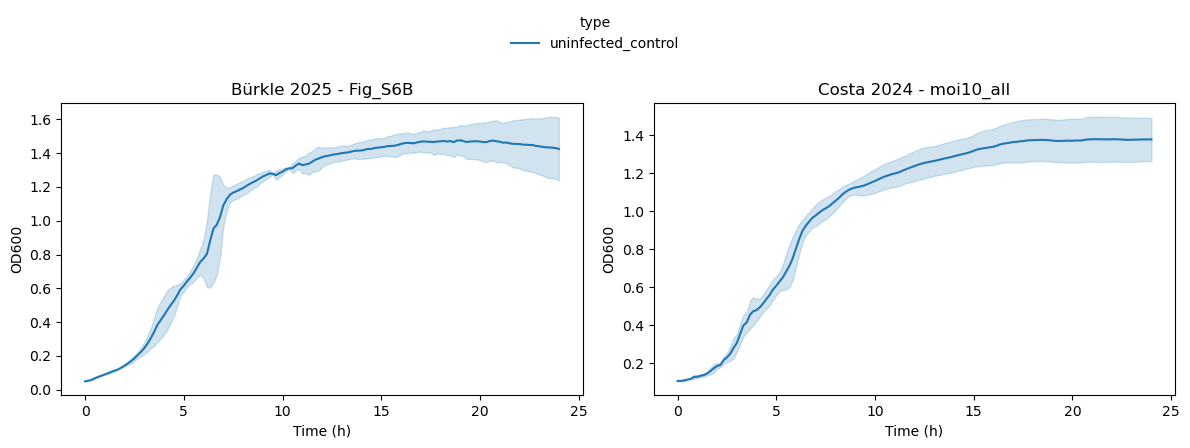

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

burkle_controls.plot(
    ax=axes[0],
    title="Bürkle 2025 - Fig_S6B",
    filters={"isolate_id": "PAO1", "type": "uninfected_control"},
    group_by="type",
    summary="mean_sd",
    time_unit="h",
)
costa_controls.plot(
    ax=axes[1],
    title="Costa 2024 - moi10_all",
    filters={"isolate_id": "PAO1", "type": "uninfected_control"},
    group_by="type",
    summary="mean_sd",
    time_unit="h",
)

plt.show()
